# Real estate price prediction


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    PolynomialFeatures,
)

from sklearn.experimental import enable_iterative_imputer

from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold, cross_validate, GridSearchCV

Read the csv files


In [2]:
X_df = pd.read_csv("../data/real_state/X.csv", index_col="id_annonce")
y_df = pd.read_csv("../data/real_state/y.csv", index_col="id_annonce")

## Entendimiento de Datos

In [3]:
X_df.info()

<class 'pandas.DataFrame'>
Index: 37368 entries, 35996577 to 35748883
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   property_type                37368 non-null  str    
 1   approximate_latitude         37368 non-null  float64
 2   approximate_longitude        37368 non-null  float64
 3   city                         37368 non-null  str    
 4   postal_code                  37368 non-null  int64  
 5   size                         36856 non-null  float64
 6   floor                        9743 non-null   float64
 7   land_size                    15581 non-null  float64
 8   energy_performance_value     19068 non-null  float64
 9   energy_performance_category  19068 non-null  str    
 10  ghg_value                    18530 non-null  float64
 11  ghg_category                 18530 non-null  str    
 12  exposition                   9094 non-null   str    
 13  nb_rooms              

In [4]:
y_df.info()

<class 'pandas.DataFrame'>
Index: 37368 entries, 35996577 to 35748883
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   37368 non-null  float64
dtypes: float64(1)
memory usage: 583.9 KB


In [5]:
# describes the dataset
def describe(df):
    unique = []
    for col in df.columns:
        unique.append(df[col].unique())
    unique_series = pd.Series(unique, index=df.columns, name="unique")

    return pd.concat(
        [
            df.dtypes.rename("dtype"),
            df.isna().sum().rename("missing"),
            round(df.isna().sum() / len(df) * 100, 1).rename("%null"),
            df.nunique().rename("nunique"),
            unique_series,
        ],
        axis=1,
    )


describe(X_df)

,dtype,missing,%null,nunique,unique
property_type,str,0,0.0,22,"[appartement, maison, propriété, divers, duple..."
approximate_latitude,float64,0,0.0,37368,"[43.64387987003234, 45.695756723197945, 47.966..."
approximate_longitude,float64,0,0.0,37368,"[7.117182951005137, 4.89560993095212, -1.22045..."
city,str,0,0.0,8643,"[villeneuve-loubet, venissieux, moutiers, cord..."
postal_code,int64,0,0.0,4726,"[6270, 69200, 35130, 44360, 69007, 91380, 9220..."
size,float64,512,1.4,4478,"[63.0, 90.0, 61.0, 142.0, 88.0, 92.0, 1758.0, ..."
floor,float64,27625,73.9,24,"[nan, 3.0, 5.0, 1.0, 2.0, 55.0, 6.0, 4.0, 8.0,..."
land_size,float64,21787,58.3,3721,"[nan, 370.0, 764.0, 25700.0, 392.0, 2600.0, 78..."
energy_performance_value,float64,18300,49.0,642,"[nan, 223.0, 217.0, 161.0, 193.0, 89.0, 220.0,..."
energy_performance_category,str,18300,49.0,7,"[nan, D, B, C, A, E, F, G]"


Para ciertos features la cantidad de nulos es muy alto por lo que si los eliminamos perderiamos gran parte de nuestro dataset.


In [6]:
def describe(df: pd.DataFrame, columns: list[str] = []):

    result_df = df.drop(columns=columns).describe(
        percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
    )

    result_df.loc["skew"] = df.drop(columns=columns).select_dtypes(exclude="str").skew()
    result_df.loc["kurt"] = df.drop(columns=columns).select_dtypes(exclude="str").kurt()

    return result_df


describe(
    X_df,
    columns=[
        "approximate_latitude",
        "approximate_longitude",
        "postal_code",
        "nb_boxes",
        "nb_photos",
        "nb_parking_places",
        "has_a_balcony",
        "nb_terraces",
        "has_a_cellar",
        "has_a_garage",
        "has_air_conditioning",
        "last_floor",
        "upper_floors",
    ],
)

,size,floor,land_size,energy_performance_value,ghg_value,nb_rooms,nb_bedrooms,nb_bathrooms
count,36856.000000,9743.000000,1.558100e+04,19068.000000,18530.000000,35802.000000,34635.000000,24095.000000
mean,1088.831615,3.479524,3.995665e+03,205.385148,31.845548,4.245405,2.864877,0.920730
std,5555.320867,6.725577,5.441595e+04,790.501769,310.576209,2.987782,2.156517,0.270778
min,1.000000,1.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,1.000000,3.620000e+02,125.000000,8.000000,3.000000,2.000000,1.000000
50%,115.000000,2.000000,7.950000e+02,180.000000,16.000000,4.000000,3.000000,1.000000
75%,235.250000,4.000000,1.841000e+03,239.000000,36.000000,5.000000,4.000000,1.000000
90%,2750.000000,5.000000,4.950000e+03,315.000000,55.000000,7.000000,5.000000,1.000000
95%,6932.750000,7.000000,1.000000e+04,371.000000,69.000000,9.000000,6.000000,1.000000
99%,13127.000000,55.000000,5.000000e+04,510.000000,102.710000,13.990000,9.000000,1.000000


Analizamos a mas detalle nuestros features numericos los cuales tienen colas muy largas y se puede definir como leptokutosis, para la variable skewness casi todas nuestras features son positivas hacia la derecha excepto la variable nb_bathrooms que es negativa e indica una un cola larga hacia la izquierda.

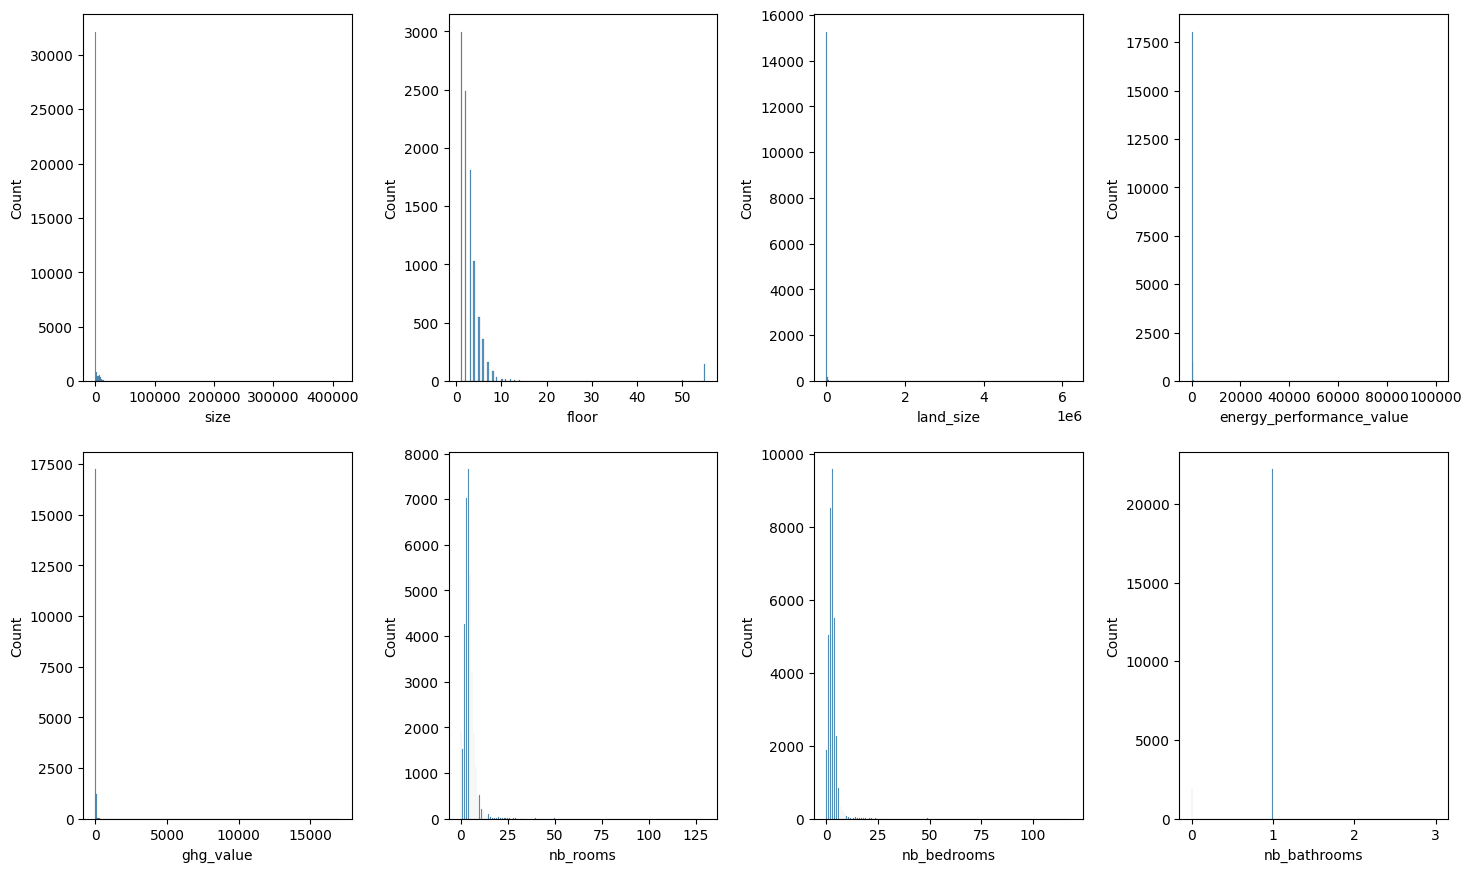

In [7]:
def histplot(df, columns=[]):
    new_df = df.drop(columns=columns).select_dtypes(exclude="str")
    count = len(list(new_df.columns))

    fig, axes = plt.subplots(count // 4, 4, figsize=(15, 9))
    axes = axes.ravel()

    for ax, col in zip(axes, new_df.columns):
        sns.histplot(df[col], ax=ax)

    fig.tight_layout(pad=1.7)


histplot(
    X_df,
    columns=[
        "approximate_latitude",
        "approximate_longitude",
        "postal_code",
        "nb_boxes",
        "nb_photos",
        "nb_parking_places",
        "has_a_balcony",
        "nb_terraces",
        "has_a_cellar",
        "has_a_garage",
        "has_air_conditioning",
        "last_floor",
        "upper_floors",
    ],
)

Confirmamos nuestros hallazgos el feature nb_bathrooms tiene una moda de 1 baño y hay muchas propiedades que no tienen baño habria que correlacionar con el precio de la vivienda si es un factor determinante.

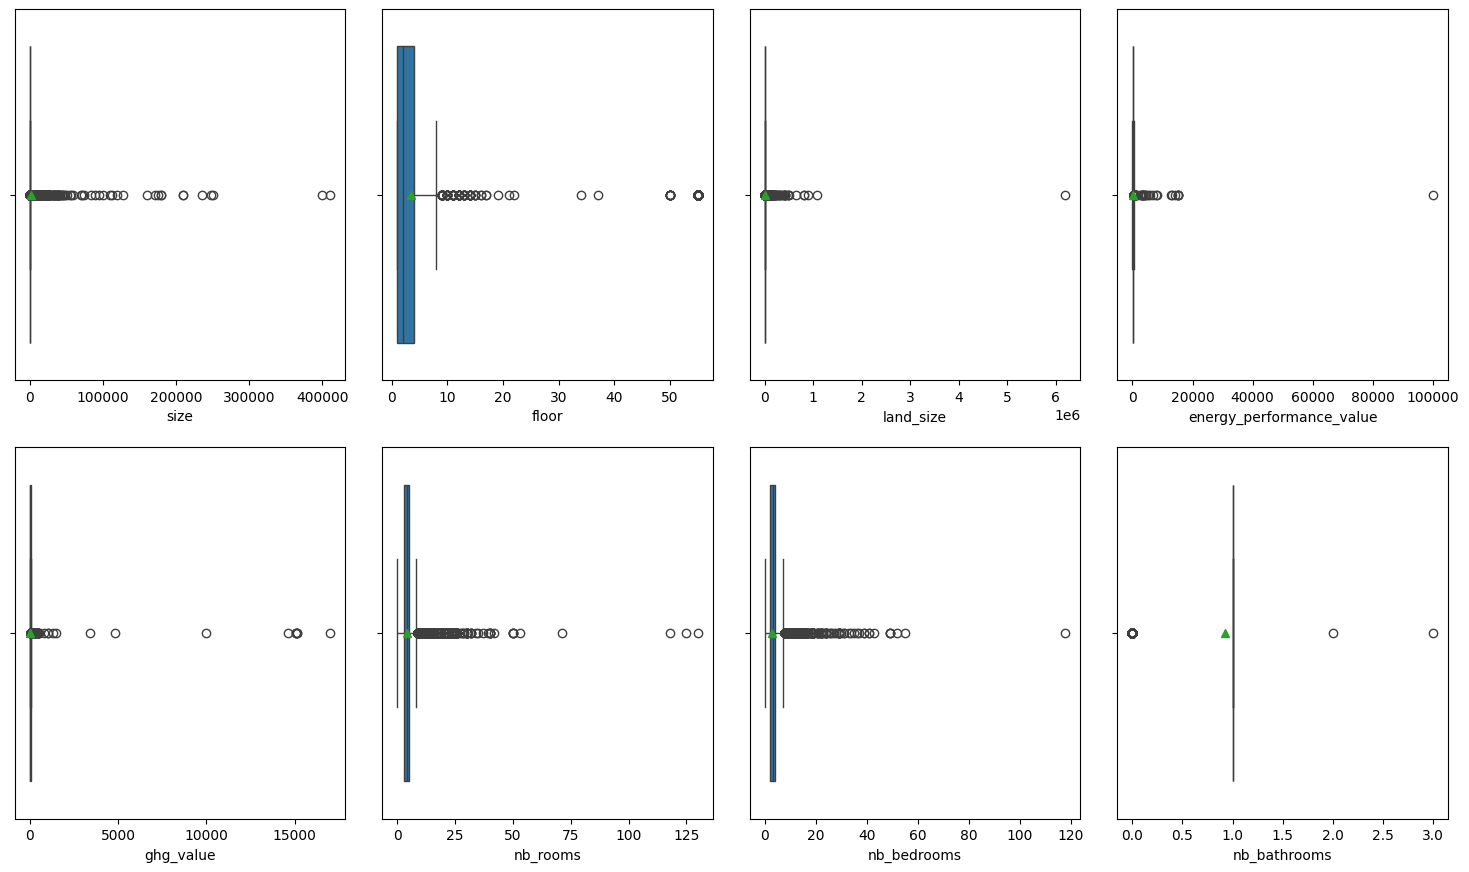

In [8]:
def boxplot(df, columns=[]):
    new_df = df.drop(columns=columns).select_dtypes(include=np.number)
    count = len(list(new_df.columns))

    fig, axes = plt.subplots(count // 4, 4, figsize=(15, 9))
    axes = axes.ravel()

    for ax, col in zip(axes, new_df.columns):
        sns.boxplot(x=df[col], ax=ax, showmeans=True)

    fig.tight_layout(pad=1.7)


boxplot(
    X_df,
    columns=[
        "approximate_latitude",
        "approximate_longitude",
        "postal_code",
        "nb_boxes",
        "nb_photos",
        "nb_parking_places",
        "has_a_balcony",
        "nb_terraces",
        "has_a_cellar",
        "has_a_garage",
        "has_air_conditioning",
        "last_floor",
        "upper_floors",
    ],
)

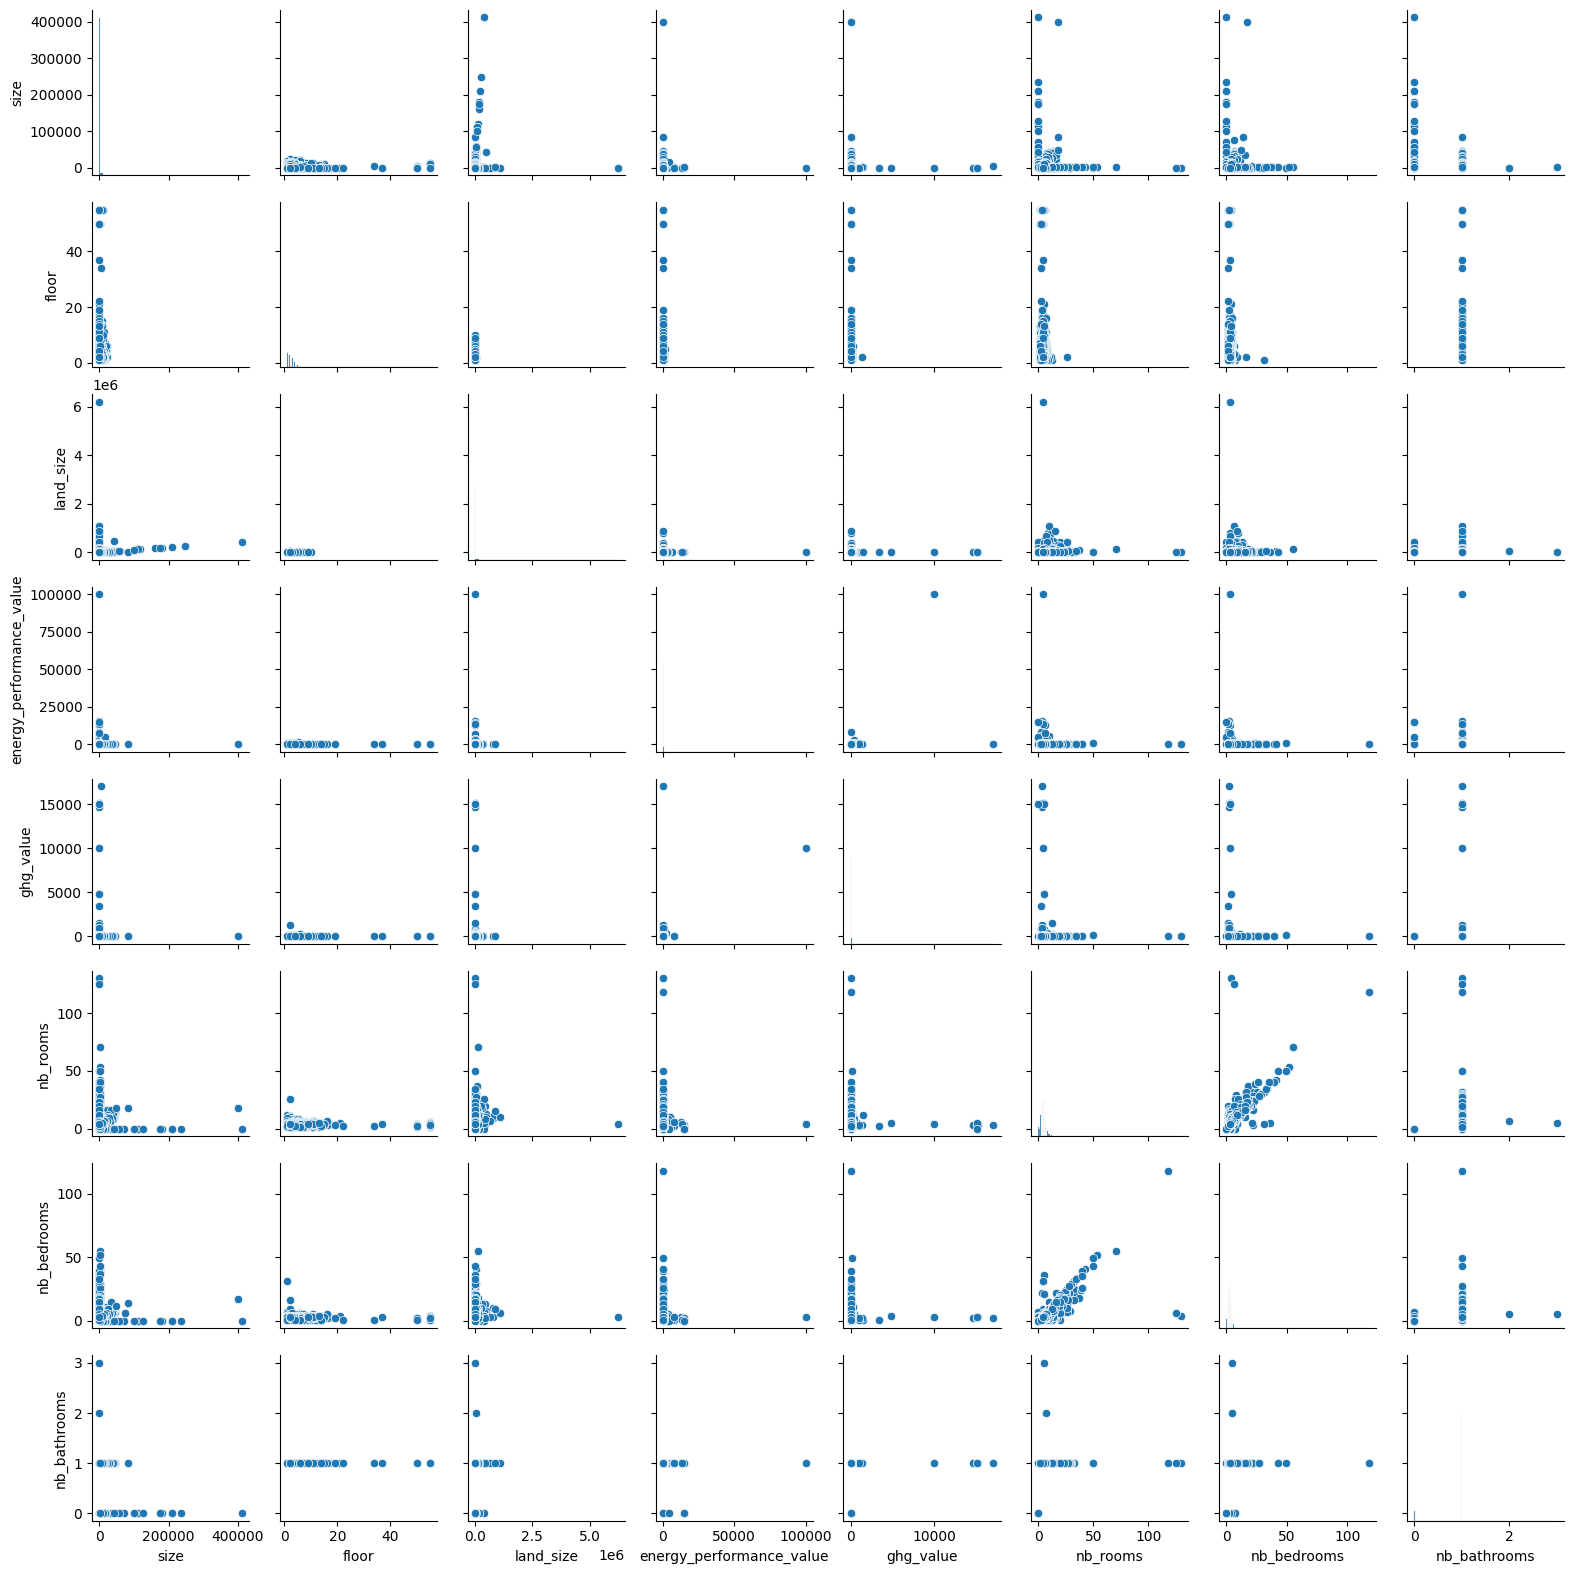

In [9]:
def pairplot(df, columns=[]):
    new_df = df.drop(columns=columns).select_dtypes(include=np.number)
    sns.pairplot(new_df, height=2)


pairplot(
    X_df,
    columns=[
        "approximate_latitude",
        "approximate_longitude",
        "postal_code",
        "nb_boxes",
        "nb_photos",
        "nb_parking_places",
        "has_a_balcony",
        "nb_terraces",
        "has_a_cellar",
        "has_a_garage",
        "has_air_conditioning",
        "last_floor",
        "upper_floors",
    ],
)

Exploramos si existe una correlacion entre las variables y encontramos linealidad entre los features nb_rooms y nb_bedrooms.

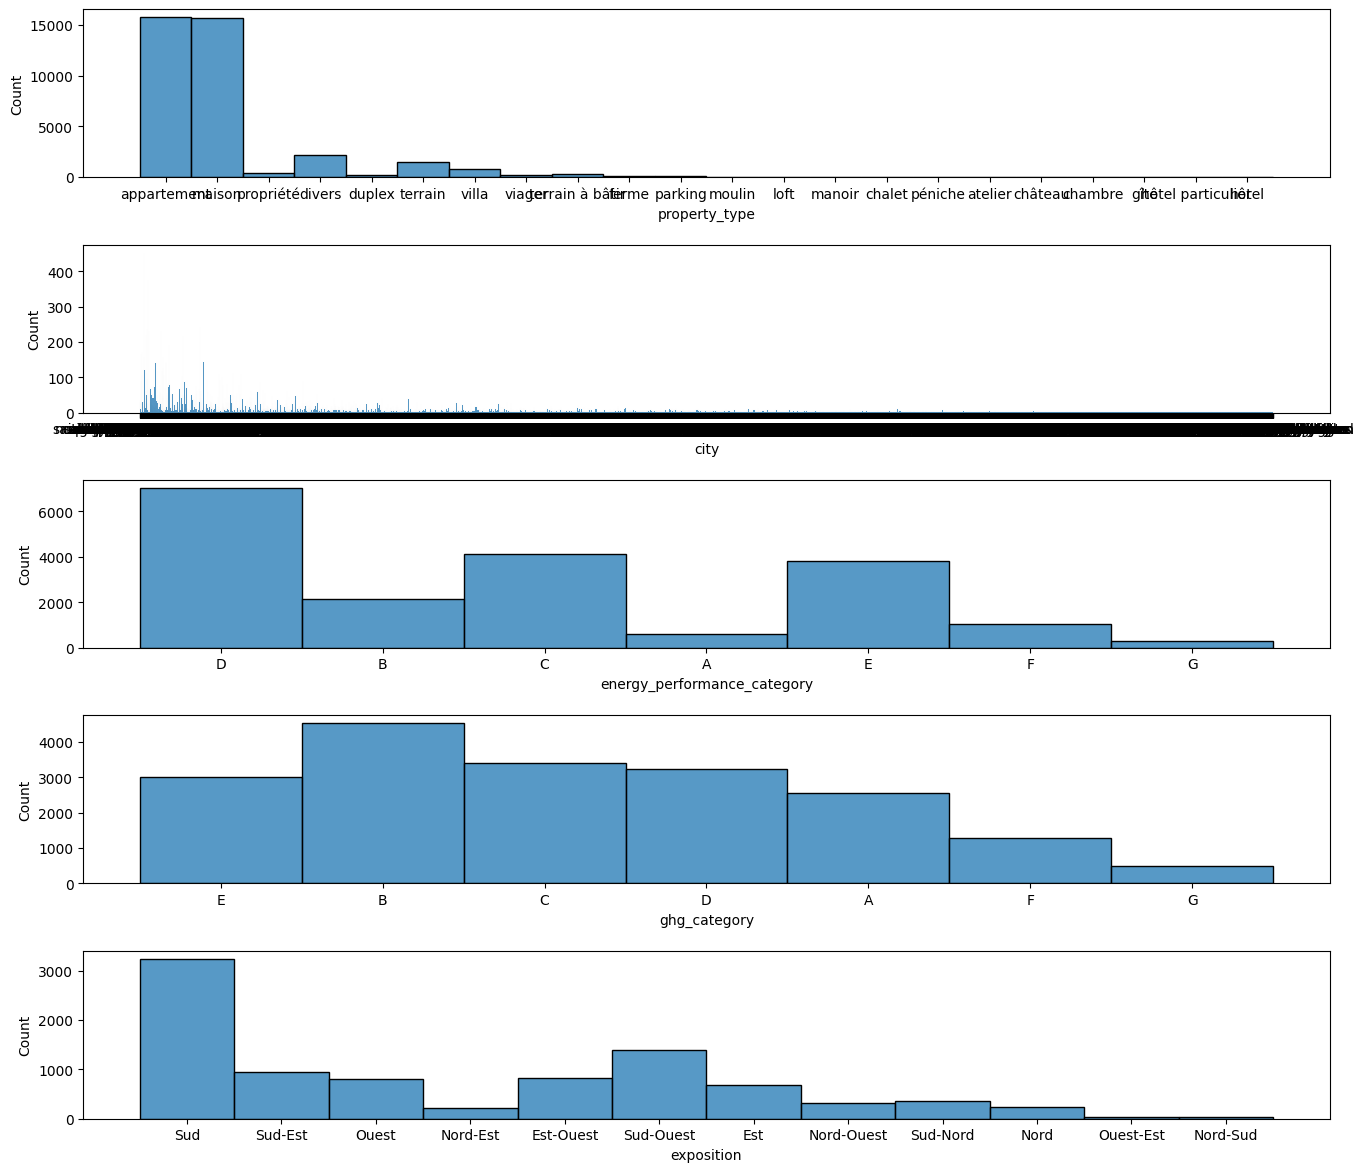

In [10]:
def cat_hist(df):
    new_df = df.select_dtypes(include="str")

    count = len(list(new_df.columns))

    fig, axes = plt.subplots(count, 1, figsize=(14, 12))
    axes = axes.ravel()

    for ax, col in zip(axes, new_df.columns):
        sns.histplot(x=df[col], ax=ax)

    fig.tight_layout(pad=1.7)

cat_hist(X_df)

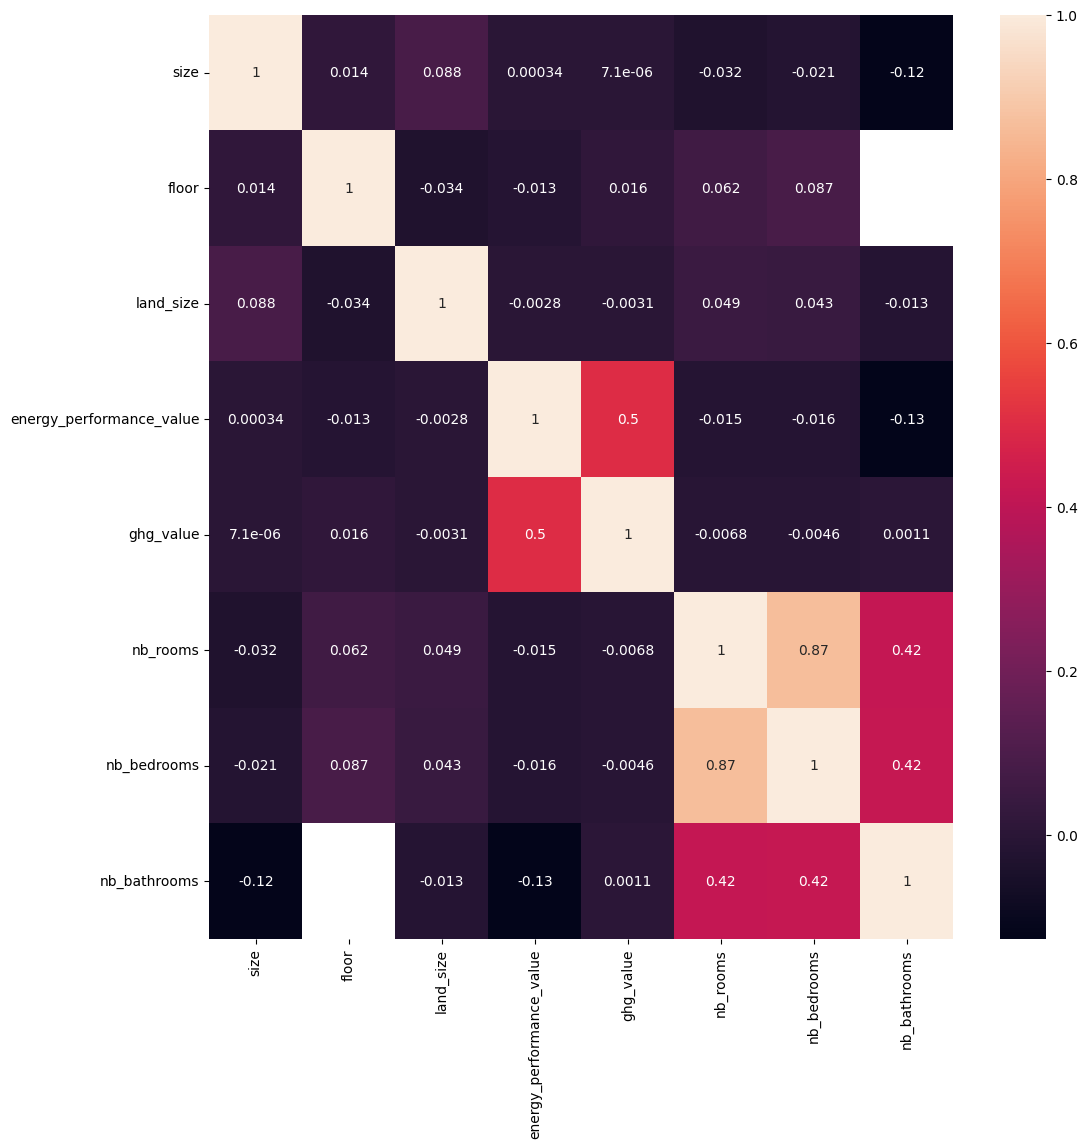

In [11]:
def corr(df, columns=[]):
    new_df = df.drop(columns=columns).select_dtypes(include=np.number)
    corr = new_df.corr(method="pearson")
    plt.figure(figsize=(12,12))
    sns.heatmap(corr, xticklabels=new_df.columns, yticklabels=new_df.columns, annot=True)


corr(
    X_df,
    columns=[
        "approximate_latitude",
        "approximate_longitude",
        "postal_code",
        "nb_boxes",
        "nb_photos",
        "nb_parking_places",
        "has_a_balcony",
        "nb_terraces",
        "has_a_cellar",
        "has_a_garage",
        "has_air_conditioning",
        "last_floor",
        "upper_floors",
    ],
)

Encontramos cierta correlación entre los features ghg_value y energy_performance_value y las variables nb_bathrooms, nb_rooms y nb_bedrooms.

<Axes: >

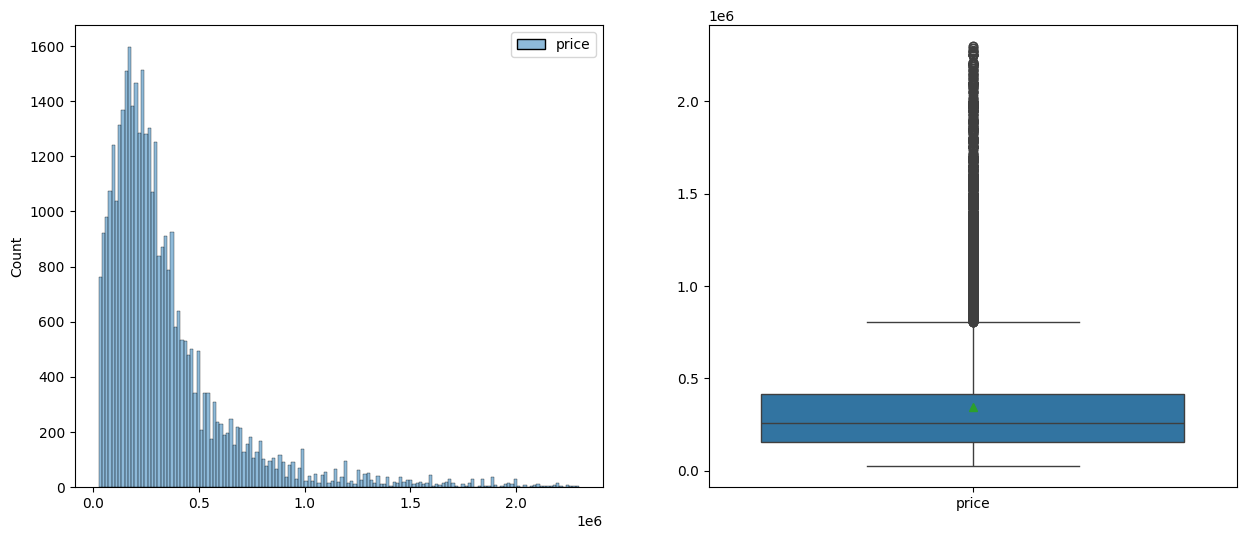

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(y_df, ax=ax[0])
sns.boxplot(y_df, ax=ax[1], showmeans=True)

In [13]:
y_df.describe()

,price
count,3.736800e+04
mean,3.432213e+05
std,3.089129e+05
min,2.446500e+04
25%,1.554625e+05
50%,2.552500e+05
75%,4.150000e+05
max,2.299000e+06


## Preprocesamiento de Datos

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_df,
    y_df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "median_num_imputer",
            Pipeline(
                [
                    (
                        "imputer",
                        SimpleImputer(strategy="median"),
                    ),
                    (
                        "encoder",
                        MinMaxScaler(),
                    ),
                ]
            ),
            ["nb_bathrooms", "nb_bedrooms", "nb_rooms", "size"],
        ),
        (
            "mode_cat",
            Pipeline(
                [
                    (
                        "imputer",
                        SimpleImputer(strategy="most_frequent"),
                    ),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="infrequent_if_exist",
                            drop="first",
                        ),
                    ),
                ]
            ),
            ["exposition", "ghg_category", "energy_performance_category"],
        ),
        (
            "knn_num",
            Pipeline(
                [
                    (
                        "impute",
                        IterativeImputer(estimator=LinearRegression()),
                    ),
                    (
                        "encoder",
                        StandardScaler(),
                    ),
                ]
            ),
            ["ghg_value", "energy_performance_value", "land_size", "floor"],
        ),
        (
            "cat_encoder",
            OneHotEncoder(handle_unknown="infrequent_if_exist", drop="first"),
            ["property_type"],
        ),
    ],
    remainder="drop",
    sparse_threshold=0,
)

In [16]:
preprocessor.fit(X_train, y_train)

X_train = preprocessor.transform(X_train)
X_test = preprocessor.transform(X_test)

## Modelo y Evaluacion

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"El score r2: {r2}")
print(f"El score mae: {mae}")

El score r2: 0.15037074728808553
El score mae: 182329.89234567425


In [19]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)

model = LinearRegression()

cv_results = cross_validate(
    estimator=model,
    X=X_train,
    y=y_train,
    cv=cv,
    return_train_score=True,
    return_estimator=True,
    scoring="neg_mean_absolute_error",  # el algoritmo de optimización que usa sklearn maximisa este valor.
)

# cambiamos el signo para obtener MAE
df_scores = pd.DataFrame(
    {"train_score": -cv_results["train_score"], "test_score": -cv_results["test_score"]}
)
df_scores

,train_score,test_score
0,180226.573192,184184.944972
1,181131.574289,176562.514359
2,180255.378148,184637.440754
3,179955.778238,185310.427118
4,181240.362808,177348.418007
5,180815.102514,177732.384081
6,180532.673755,181168.341541
7,180633.104315,180929.798375
8,179923.894901,184564.359949
9,180743.156426,180931.625898


In [20]:
print("Mean cross-validation MAE:", df_scores["test_score"].mean())
print("Standard deviation of cross-validation MAE:", df_scores["test_score"].std())

Mean cross-validation MAE: 181337.02550524106
Standard deviation of cross-validation MAE: 3287.4173823699825


In [21]:
def get_errors_for(X, y, cv_results):
    errores = []
    for i, (train_index, test_index) in enumerate(cv.split(X, y)):
        X_test_fold = X[test_index]
        y_test_fold = y.iloc[test_index]

        model = cv_results["estimator"][i]
        y_pred_fold = model.predict(X_test_fold)
        errores_fold = y_test_fold.values.ravel() - y_pred_fold.ravel()
        errores.extend(errores_fold)

    errores = np.array(errores)

    return errores


errores = get_errors_for(X_train, y_train, cv_results)

len(errores), len(y_train)

(29894, 29894)

In [22]:
loc, scale = stats.laplace.fit(errores)
ks_stat, p_value = stats.kstest(errores, "laplace", args=(loc, scale))
print(f"KS stat: {ks_stat:.4f}, p-value: {p_value:.4f}")

KS stat: 0.1043, p-value: 0.0000


In [23]:
excess_kurt = stats.kurtosis(errores)
print(f"Excess kurtosis: {excess_kurt:.4f}")

Excess kurtosis: 13.1182


In [24]:
cv_grid = KFold(n_splits=5, shuffle=True, random_state=42)

model_hr = HuberRegressor(
    max_iter=10000, alpha=0, warm_start=True, fit_intercept=False, tol=1e-05
)

model_grid_search = GridSearchCV(
    estimator=model_hr,
    param_grid={
        "epsilon": [
            1.25,
            1.35,
            1.5,
            1.75,
        ]
    },  # Se recomienda un rango entre 1 y 2
    scoring="neg_mean_absolute_error",
    cv=cv_grid,  # estrategia de separación del conjunto de datos
    verbose=3,  # Al final entrena el modelo con los mejores parametros en todos los datos
)

cv = KFold(n_splits=3, shuffle=True, random_state=6)
cv_results = cross_validate(
    estimator=model_grid_search,
    X=X_train,
    y=np.squeeze(y_train),
    cv=cv,
    # return_train_score=True,
    return_estimator=True,
    scoring="neg_mean_absolute_error",  # el algoritmo de optimización que usa sklearn maximisa este valor.
)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END ................epsilon=1.25;, score=-167635.402 total time=   0.8s
[CV 2/5] END ................epsilon=1.25;, score=-169085.767 total time=   0.7s
[CV 3/5] END ................epsilon=1.25;, score=-170010.464 total time=   0.8s
[CV 4/5] END ................epsilon=1.25;, score=-169730.726 total time=   0.7s
[CV 5/5] END ................epsilon=1.25;, score=-161365.436 total time=   0.7s
[CV 1/5] END ................epsilon=1.35;, score=-167812.345 total time=   0.8s
[CV 2/5] END ................epsilon=1.35;, score=-169334.849 total time=   0.6s
[CV 3/5] END ................epsilon=1.35;, score=-170158.112 total time=   0.9s
[CV 4/5] END ................epsilon=1.35;, score=-170051.253 total time=   0.7s
[CV 5/5] END ................epsilon=1.35;, score=-161749.092 total time=   0.8s
[CV 1/5] END .................epsilon=1.5;, score=-168345.850 total time=   0.7s
[CV 2/5] END .................epsilon=1.5;, score

In [25]:
for cv_fold, estimator_in_fold in enumerate(cv_results["estimator"]):
    print(
        f"Best hyperparameters for fold #{cv_fold + 1}:\n"
        f"{estimator_in_fold.best_params_}"
    )

Best hyperparameters for fold #1:
{'epsilon': 1.25}
Best hyperparameters for fold #2:
{'epsilon': 1.25}
Best hyperparameters for fold #3:
{'epsilon': 1.25}


In [26]:
df_scores = pd.DataFrame({"test_score": -cv_results["test_score"]})
df_scores

,test_score
0,170784.192918
1,167687.519229
2,167338.555128


In [27]:
print("Mean cross-validation MAE:", df_scores["test_score"].mean())
print("Standard deviation of cross-validation MAE:", df_scores["test_score"].std())

Mean cross-validation MAE: 168603.4224250097
Standard deviation of cross-validation MAE: 1896.645444882436


In [28]:
errores = get_errors_for(X_train, y_train, cv_results)

loc, scale = stats.laplace.fit(errores)
ks_stat, p_value = stats.kstest(errores, "laplace", args=(loc, scale))
print(f"KS stat: {ks_stat:.4f}, p-value: {p_value:.4f}")

excess_kurt = stats.kurtosis(errores)
print(f"Excess kurtosis: {excess_kurt:.4f}")

KS stat: 0.1172, p-value: 0.0000
Excess kurtosis: 13.2130


In [29]:
polynomial_features = PolynomialFeatures(degree=2, interaction_only=True).set_output(
    transform="pandas"
)

X_train_poly = polynomial_features.fit_transform(X_train)

In [30]:
cv_grid = KFold(n_splits=5, shuffle=True, random_state=42)

model_hr = HuberRegressor(
    max_iter=5000, alpha=0, warm_start=True, fit_intercept=False, tol=1e-05
)

model_grid_search = GridSearchCV(
    estimator=model_hr,
    param_grid={
        "epsilon": [
            1.25,
            1.35,
            1.5,
            1.75,
        ]
    },  # Se recomienda un rango entre 1 y 2
    scoring="neg_mean_absolute_error",
    cv=cv_grid,  # estrategia de separación del conjunto de datos
    verbose=3,  # Al final entrena el modelo con los mejores parametros en todos los datos
)

cv = KFold(n_splits=3, shuffle=True, random_state=6)
cv_results = cross_validate(
    estimator=model_grid_search,
    X=X_train_poly,
    y=np.squeeze(y_train),
    cv=cv,
    # return_train_score=True,
    return_estimator=True,
    scoring="neg_mean_absolute_error",  # el algoritmo de optimización que usa sklearn maximisa este valor.
)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/Users/jmanuelc87/Documents/Project Repositories/bourbaki-track-ciencia-datos/.venv/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV 1/5] END ................epsilon=1.25;, score=-164689.628 total time= 1.1min


/Users/jmanuelc87/Documents/Project Repositories/bourbaki-track-ciencia-datos/.venv/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV 2/5] END ................epsilon=1.25;, score=-171624.759 total time= 1.0min


...

/Users/jmanuelc87/Documents/Project Repositories/bourbaki-track-ciencia-datos/.venv/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV 4/5] END ................epsilon=1.75;, score=-171391.472 total time= 1.1min


/Users/jmanuelc87/Documents/Project Repositories/bourbaki-track-ciencia-datos/.venv/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV 5/5] END ................epsilon=1.75;, score=-170988.134 total time= 1.1min


/Users/jmanuelc87/Documents/Project Repositories/bourbaki-track-ciencia-datos/.venv/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [31]:
df_scores = pd.DataFrame({"test_score": -cv_results["test_score"]})
df_scores

,test_score
0,176403.325588
1,167783.699905
2,174265.700378


In [32]:
idx = np.argmax(cv_results["test_score"])
best_grid = cv_results["estimator"][idx]
best_model = best_grid.best_estimator_

In [33]:
X_test_poly = polynomial_features.transform(X_test)
y_pred = best_model.predict(X_test_poly)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"El score r2: {r2}")
print(f"El score mae: {mae}")

El score r2: 0.12118954456167064
El score mae: 167733.51638860456
